## 1. Методы оптимизации

In [40]:
from time import time

import numpy as np
from scipy.optimize import minimize

from optimization import simplex_method, Gradient_Descent, Steepest_Descent, Conjugate_Gradient, Newtone_Method

def f1(x):
    return 100 * (x[1] - x[0] ** 2) ** 2 + 5 * (1 - x[0]) ** 2
def f2(x):
    return (x[0] ** 2 + x[1] - 11) ** 2 + (x[0] + x[1] ** 2 - 7) ** 2

def grad_f1(x):
    return np.array([-400 * x[0] * (x[1] - x[0] ** 2) - 10 * (1 - x[0]), 200 * (x[1] - x[0] ** 2)])
def grad_f2(x):
    return np.array([4 * (x[0] ** 2 + x[1] - 11) * x[0] + 2 * (x[0] + x[1] ** 2 - 7), 2 * (x[0] ** 2 + x[1] - 11) + 4 * (x[0] + x[1] ** 2 - 7) * x[1]])

def grad2_f1(x):
    return np.array([[-400 * (x[1] - x[0] ** 2) + 800 * x[0] ** 2 + 10, -400 * x[0]], [-400 * x[0], 200]])
def grad2_f2(x):
    return np.array([[4 * (3 * x[0] ** 2 + x[1] - 11), 4 * x[0]], [4 * x[0], 2 + 4 * (x[0] + 3 * x[1] ** 2 - 7)]])


result = minimize(f1, [0, 0], jac=grad_f1)
print(f'Для первой функции точка минимума: {result.x}, значение: {f1(result.x)}')

result = minimize(f2, [0, 0], jac=grad_f2)
print(f'Для второй функции точка минимума: {result.x}, значение: {f2(result.x)}')

Для первой функции точка минимума: [1.00000001 1.00000003], значение: 1.3780752399848105e-15
Для второй функции точка минимума: [2.99999995 2.        ], значение: 1.0569835706588071e-13


### 1) Симплекс-метод

Для первой функции

In [43]:
start = time()
x, iters = simplex_method(f1, x_start=[100, 100], eps=1e-8, count_iters=True)
dt = time() - start
print(
    f'Точка минимума: {x}',
    f'Значение: {f1(x)}',
    f'Время: {dt}',
    f'Количество итераций: {iters}',
    sep='\n')

Точка минимума: [1. 1.]
Значение: 2.3053096939658624e-17
Время: 0.006453275680541992
Количество итераций: 210


Для второй функции

In [44]:
start = time()
x, iters = simplex_method(f2, x_start=[50, 50], eps=1e-8, count_iters=True)
dt = time() - start
print(
    f'Точка минимума: {x}',
    f'Значение: {f2(x)}',
    f'Время: {dt}',
    f'Количество итераций: {iters}',
    sep='\n')

Точка минимума: [3.         2.00000001]
Значение: 1.3057115834697812e-15
Время: 0.002195596694946289
Количество итераций: 89


### 2) Метод градиентного спуска

Для первой функции

In [47]:
start = time()
gd = Gradient_Descent(f1, grad_f1, x_start=[5, 5], lr=1e-4, eps_grad=1e-8, eps_func=1e-8, eps_x=1e-8)
dt = time() - start
print(
    f'Точка минимума: {gd.x}',
    f'Значение: {f1(gd.x)}',
    f'Время: {dt}',
    f'Количество итераций: {gd.iters}',
    sep='\n')

Точка минимума: [1.00223943 1.00452869]
Значение: 2.52760707612651e-05
Время: 0.6674509048461914
Количество итераций: 44584


Для второй функции

In [46]:
start = time()
gd = Gradient_Descent(f2, grad_f2, x_start=[5, 5], lr=1e-4, eps_grad=1e-8, eps_func=1e-8, eps_x=1e-8)
dt = time() - start
print(
    f'Точка минимума: {gd.x}',
    f'Значение: {f2(gd.x)}',
    f'Время: {dt}',
    f'Количество итераций: {gd.iters}',
    sep='\n')

Точка минимума: [2.9998515  2.00035836]
Значение: 1.9351093949576947e-06
Время: 0.07436990737915039
Количество итераций: 2860


### 3) Метод наискорейшего спуска

Для первой функции

In [48]:
start = time()
sd = Steepest_Descent(f1, grad_f1, x_start=[100, -100], eps_grad=1e-8, eps_func=1e-8, eps_x=1e-8)
dt = time() - start

print(
    f'Точка минимума: {sd.x}',
    f'Значение: {f1(sd.x)}',
    f'Время: {dt}',
    f'Количество итераций: {sd.iters}',
    sep='\n')

Точка минимума: [0.99997762 0.99994795]
Значение: 7.815372617088123e-09
Время: 0.1962265968322754
Количество итераций: 960


Для второй функции

In [49]:
start = time()
sd = Steepest_Descent(f2, grad_f2, x_start=[100, -100], eps_grad=1e-8, eps_func=1e-8, eps_x=1e-8)
dt = time() - start

print(
    f'Точка минимума: {sd.x}',
    f'Значение: {f2(sd.x)}',
    f'Время: {dt}',
    f'Количество итераций: {sd.iters}',
    sep='\n')

Точка минимума: [-2.80511776  3.13131142]
Значение: 5.1886903939956754e-11
Время: 0.0031087398529052734
Количество итераций: 10


### 4) Метод сопряжённых градиентов

Для первой функции

In [50]:
start = time()
cg = Conjugate_Gradient(f1, grad_f1, x_start=[100, -100], eps_grad=1e-8, eps_func=1e-8, eps_x=1e-8)
dt = time() - start

print(
    f'Точка минимума: {cg.x}',
    f'Значение: {f1(cg.x)}',
    f'Время: {dt}',
    f'Количество итераций: {cg.iters}',
    sep='\n')

Точка минимума: [1.00038959 1.0007856 ]
Значение: 7.62827204636947e-07
Время: 0.02932453155517578
Количество итераций: 93


Для второй функции

In [51]:
start = time()
cg = Conjugate_Gradient(f2, grad_f2, x_start=[100, -100], eps_grad=1e-8, eps_func=1e-8, eps_x=1e-8)
dt = time() - start
print(
    f'Точка минимума: {cg.x}',
    f'Значение: {f2(cg.x)}',
    f'Время: {dt}',
    f'Количество итераций: {cg.iters}',
    sep='\n')

Точка минимума: [ 3.58443079 -1.84812534]
Значение: 3.560984533358246e-10
Время: 0.0030591487884521484
Количество итераций: 7


### 5) Метод Ньютона

Для первой функции

In [52]:
start = time()
nm = Newtone_Method(f1, grad_f1, grad2_f1, x_start=[100, -100], eps_grad=1e-8, eps_func=1e-8, eps_x=1e-8)
dt = time() - start

print(
    f'Точка минимума: {nm.x}',
    f'Значение: {f1(nm.x)}',
    f'Время: {dt}',
    f'Количество итераций: {nm.iters}',
    sep='\n')

Точка минимума: [1.00000185 1.00000314]
Значение: 4.912662306305485e-11
Время: 0.05175137519836426
Количество итераций: 127


Для второй функции

In [53]:
start = time()
nm = Newtone_Method(f2, grad_f2, grad2_f2, x_start=[0, 0], eps_grad=1e-8, eps_func=1e-8, eps_x=1e-8)
dt = time() - start

print(
    f'Точка: {nm.x}',
    f'Значение: {f2(nm.x)}',
    f'Время: {dt}',
    f'Количество итераций: {nm.iters}',
    sep='\n')

Точка: [-0.27090234 -0.9229013 ]
Значение: 181.616521326891
Время: 55.36522889137268
Количество итераций: 248580


## 2. Интерполяция

Реализованы полиномы Лагранжа и Ньютона по равноотстоящим и оптимальным (Чебышева) узлам и сплайны $𝑆_{1,0}(x), 𝑆_{2,1}(x),𝑆_{3,2}(x)$

In [38]:
import numpy as np

from interpolation import compare_lagrange_and_newton, compare_splines_and_newton


def func(x):
    return 3 * x - np.cos(x) - 1


bounds = (-np.pi * 2, np.pi * 2)  # Интервал непрерывности из области определения функции f(x)

### 1) Сравнение полиномов Лагранжа и Ньютона по разным узлам

In [ ]:
pairs_of_n_and_m = ((3, 1000), (10, 1000), (30, 1000), (35, 1000))  # Кортеж из пар чисел "Количество узлов(n)" и "Количество проверочных узлов(m)"
# pairs_of_n_and_m = ((60, 1000), (100, 1000), (400, 1000))  # Ещё несколько значений
compare_lagrange_and_newton(func, pairs_of_n_and_m, bounds)

### 2) Сравнение сплайнов и полинома Ньютона

In [ ]:
d = 0
pairs_of_n_and_m = ((300, 1000), (10, 1000), (30, 1000), (35, 1000))  # Кортеж из пар чисел "Количество узлов(n)" и "Количество проверочных узлов(k)"

compare_splines_and_newton(func, pairs_of_n_and_m, bounds, d)

## 3. Аппроксимация

Реализованы МНК: нормальные уравнения, ортогональные полиномы

In [36]:
import numpy as np

from approximation import mnk_test


 |       Степень        |   Сумма квадратов    |   Сумма квадратов    |
 |       полинома       |    ошибок для МНК    |    ошибок для МНК    |
 |         (n)          |     (нормальные      |    (ортогональные    |
 |                      |      уравнения)      |      полиномы)       |
 |          1           | -7488.9066793041375  | -7488.9066793041375  |
 |          2           |  -7517.702405815846  |  -7517.702405815848  |
 |          3           |  -7546.075534289014  |  -7546.075534289018  |
 |          4           |  -7548.161313925377  |  -7548.16131392538   |
 |          5           |  -7548.821519223639  |  -7548.821519223647  |
 |          6           |  -7548.831660946645  | -7548.8316609466565  |



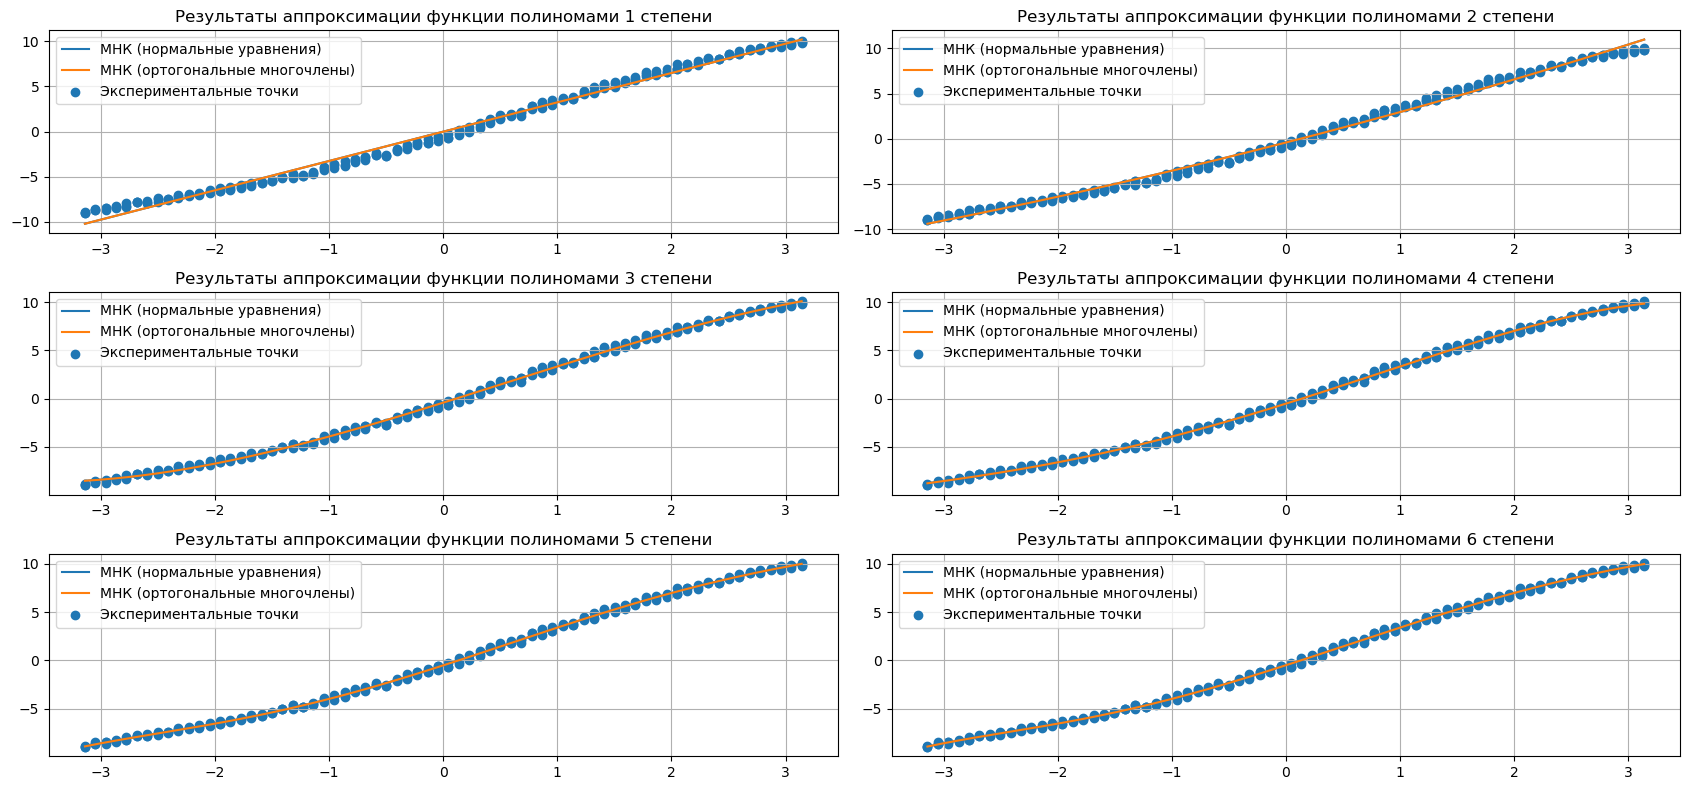

In [37]:
eps = 1.e-1  # погрешность x в функции
def func(x):
    x += (np.random.random() * 2 - 1) * eps
    return 3 * x - np.cos(x + 1)

bounds = (-np.pi, np.pi)
n_nodes = 70
values_koef = 3
mnk_test(func, bounds, n_nodes, values_koef)

## 4. Нахождение собственных чисел и векторов

In [26]:
import numpy as np

from eigen import generate_matrix, power_method, find_by_inverse_power_method, qr_algorithm

n = 5
bounds = (-100, 100)

matrix, eigenvalues = generate_matrix(n, bounds)
# Вывод
print("Сгенерированные собственные числа 𝚲:\n", np.sort(np.diag(eigenvalues)))
print("Сгенерированная матрица C^(-1)𝚲C:\n", matrix)

Сгенерированные собственные числа 𝚲:
 [-75.99526129  21.37345426  33.27501234  86.32064597  89.42055867]
Сгенерированная матрица C^(-1)𝚲C:
 [[-626.30465187 -437.17104016  -92.72829934 -224.6606784  -538.43070924]
 [1799.41110286 1196.30791866  195.66468573  607.60343396 1373.2811898 ]
 [ 170.43978807  109.28041425   70.23555185   64.7431668   139.74405056]
 [-103.60844793  -59.08932756  -34.58312141  -19.25663979  -69.27122704]
 [-704.7753579  -441.48972584  -28.88423006 -216.18394432 -466.5877689 ]]


### 1) Степенной метод

In [34]:
p_m_dig, p_m_vec = power_method(matrix)
print("Наибольшее по модулю собственное число:", p_m_dig, "\nСоответствующий собственный вектор:", p_m_vec)

Наибольшее по модулю собственное число: 89.42134095187266 
Соответствующий собственный вектор: [-0.30774104  0.89441391  0.02338578  0.00592428 -0.32363131]


### 2) Обратный степенной метод

In [33]:
i_m_dig, i_m_vec = find_by_inverse_power_method(matrix, bounds)
print("Собственные числа (отсортированы для удобства):\n", np.sort(i_m_dig), "\nМатрица собственных векторов:\n", i_m_vec)
print("Проверка:\n", i_m_vec @ np.diag(i_m_dig) @ np.linalg.inv(i_m_vec))

Собственные числа (отсортированы для удобства):
 [-75.99526129  21.37345426  33.27501234  86.32064597  89.42133819] 
Матрица собственных векторов:
 [[-0.3077408   0.32679245 -0.18098452 -0.099151    0.17376812]
 [ 0.89441389 -0.86520279 -0.42636426  0.73609853 -0.86539405]
 [ 0.02338569 -0.10707658 -0.471888    0.27149673  0.02687764]
 [ 0.00592428  0.06812201  0.6473913  -0.53160298 -0.00285324]
 [-0.32363159  0.35850359  0.37903079 -0.30334112  0.4692198 ]]
Проверка:
 [[-626.304087   -437.17059113  -92.72797068 -224.66033777 -538.43010703]
 [1799.40169244 1196.30043807  195.65921031  607.59775927 1373.27115728]
 [ 170.44060926  109.28106703   70.23602966   64.74366199  139.74492604]
 [-103.6084482   -59.08932777  -34.58312157  -19.25663995  -69.27122733]
 [-704.76858785 -441.48434415  -28.88029094 -216.17986183 -466.5805513 ]]


### 3) QR-алгоритм

In [32]:
print("Собственные числа (отсортированы для удобства):\n", np.sort(qr_algorithm(matrix)))

Собственные числа (отсортированы для удобства):
 [-75.99526129  21.37345426  33.27501234  86.32064597  89.42055867]


## 5. Интегрирование

Методы вычисления определенного интеграла при помощи составных квадратурных формул вида

$$
J(F) = \int_a^b F(x)\,dx = \int_a^b p(x)\cdot f(x)\,dx,
$$

где $p(x)$ — весовая функция.


In [ ]:
import numpy as np

from integration import Integration


def func(x: float) -> float:
    return 4.5 * np.cos(7 * x) * np.exp(-2 * x / 3) + 1.4 * np.sin(1.5 * x) * np.exp(-x / 3) + 3


bounds = 2.1, 3.3

integration = Integration(func=func, bounds=bounds)

Для формул средних прямоугольников, левых прямоугольников, трапеций и Симпсона весовая функция:

$$p(x)\equiv1$$

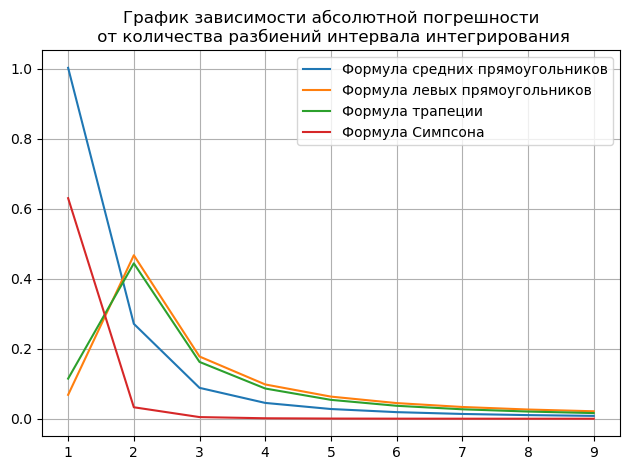

In [6]:
true_value = 2.950730
integration.integration_test_unweighted(true_value=true_value)

Для 3-точечных формул Ньютона–Кот(е)са и Гаусса весовая функция:
$$
    \frac{1}{(b-x)^{\beta}}
$$

Шаг разбиения интервала интегрирования для достижения заданной точности методом Ньютона-Котса: 1 / 64
Шаг разбиения интервала интегрирования для достижения заданной точности методом Ньютона-Котса, начиная с оптимального шага: 1 / 40
Шаг разбиения интервала интегрирования для достижения заданной точности методом Гаусса: 1 / 8
Шаг разбиения интервала интегрирования для достижения заданной точности методом Гаусса, начиная с оптимального шага: 1 / 10


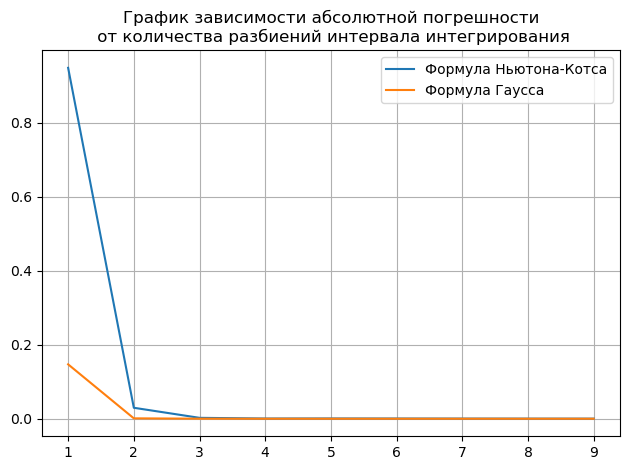

In [ ]:
# Моменты весовой функции
def find_mu(
    bounds: tuple[float, float],
    z1: float,
    z2: float,
    n: int
) -> np.ndarray:
    lower_bound = bounds[0]
    alpha = 2 / 5
    terms = np.arange(n) + 1 - alpha
    return ((z2 - lower_bound)**terms - (z1 - lower_bound)**terms) / terms

integration.find_mu = find_mu

true_value = 4.46151270533117

integration.integration_test_weighted(true_value=true_value)

## 6. Решение задачи Коши для СОДУ

Реализованы методы Рунге-Кутты с постоянным и автоматическим шагом с оценкой полной и локальной погрешности для 2, 3 и 4 порядка точности

In [ ]:
import numpy as np

from sode import SODE_Solver


def func(x, y):
    f = np.zeros(2)
    f[0] = y[1] / 14
    f[1] = -y[0] / 15
    return f

x_start=0
y_start=(np.pi / 15, np.pi / 14)
x_end=np.pi
total_err=1e-4
local_err=1e-5

2 порядок точности

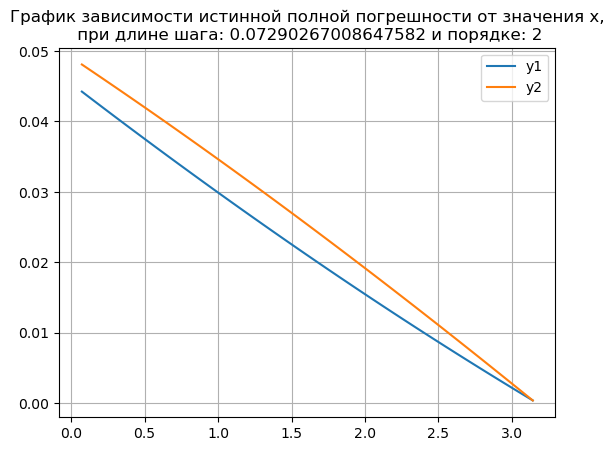

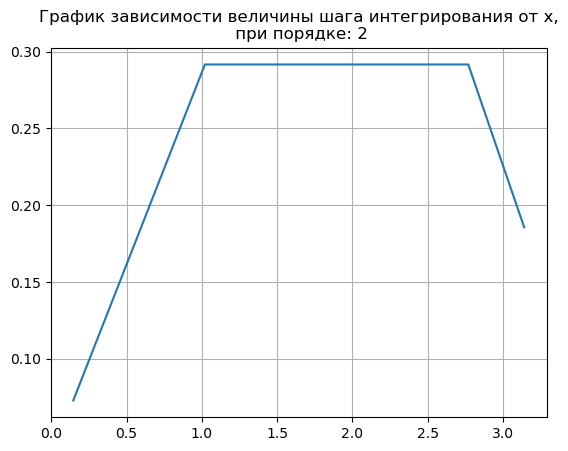

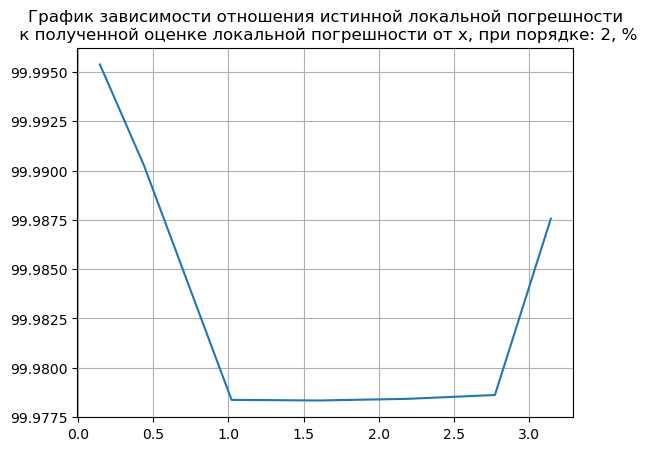

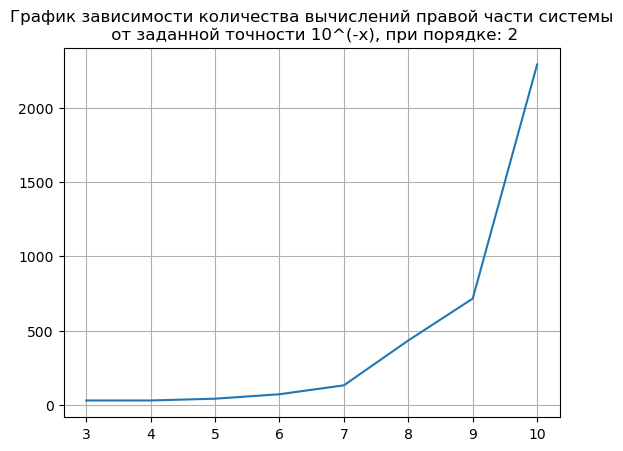

In [10]:
s2 = SODE_Solver(func=func, x_start=x_start, y_start=y_start, x_end=x_end, order=2, total_err=total_err, local_err=local_err)

s2.show_const_step()
s2.show_auto_step()

3 порядок точности

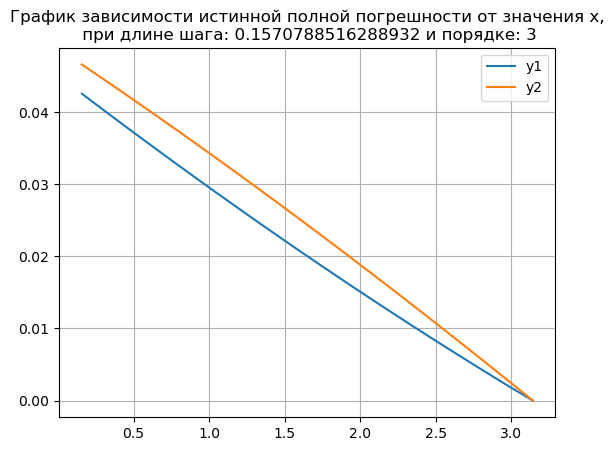

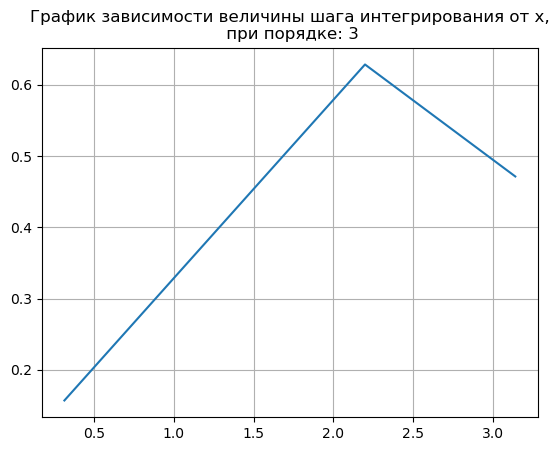

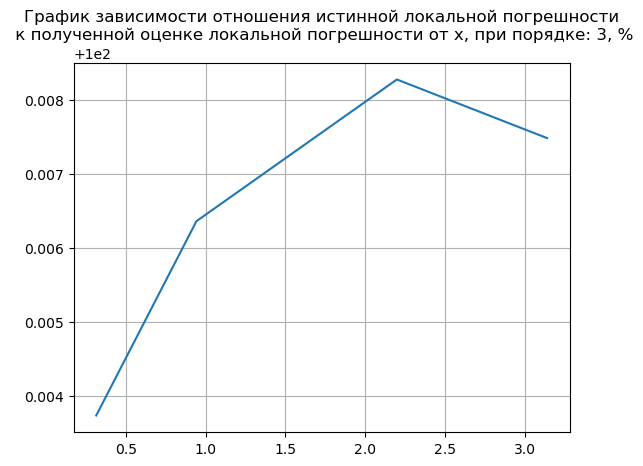

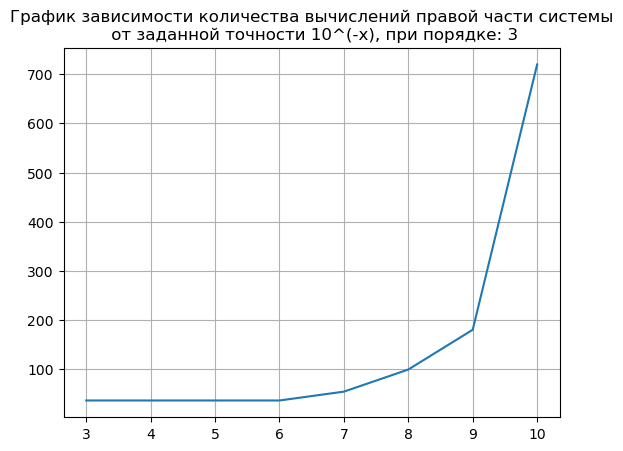

In [11]:
s3 = SODE_Solver(func=func, x_start=x_start, y_start=y_start, x_end=x_end, order=3, total_err=total_err, local_err=local_err)

s3.show_const_step()
s3.show_auto_step()


4 порядок точности

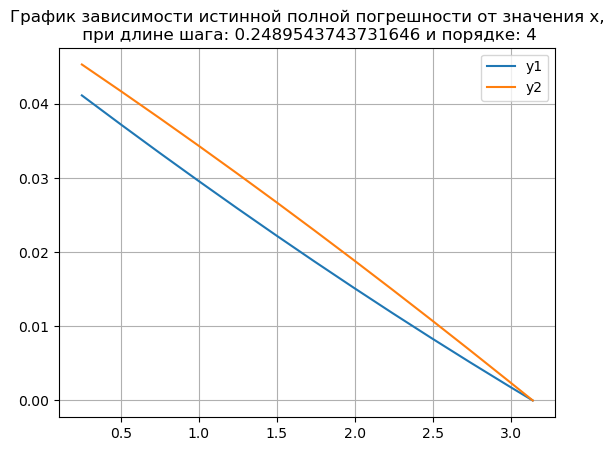

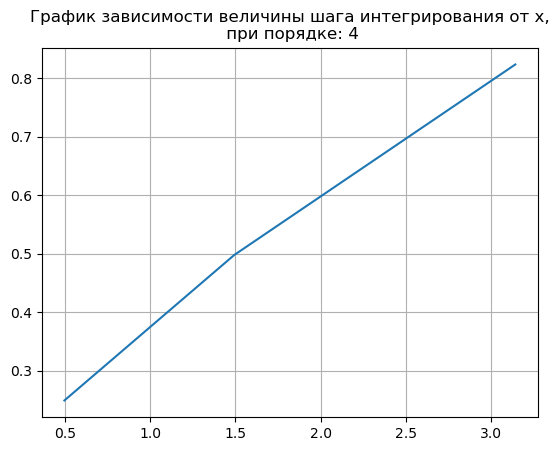

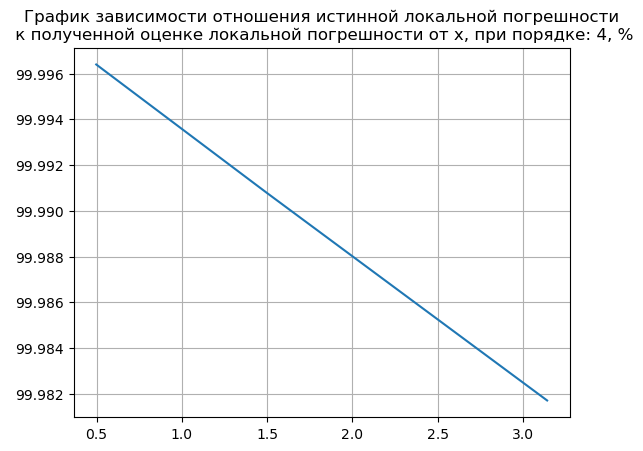

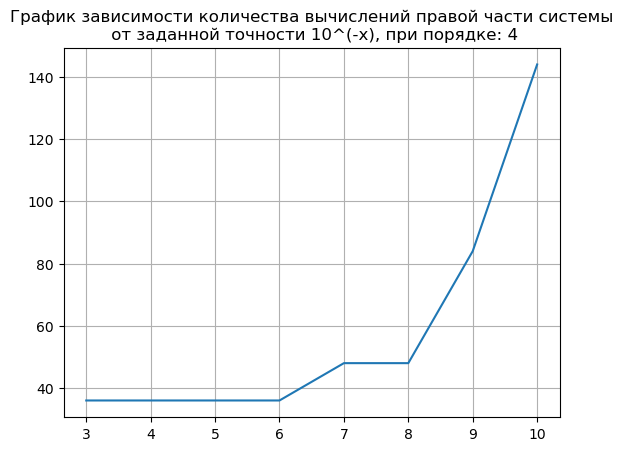

In [12]:
s4 = SODE_Solver(func=func, x_start=0, y_start=(np.pi / 15, np.pi / 14), x_end=np.pi, order=4, total_err=1e-4, local_err=1e-5)

s4.show_const_step()
s4.show_auto_step()